In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

ModuleNotFoundError: No module named 'seaborn'

In [2]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

In [4]:
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

df.head(5)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [5]:
print(df.shape)
print(df.info())

(1470, 35)
<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null 

In [6]:
attrition_rate = (
    df['Attrition']
    .value_counts(normalize=True)['Yes'] * 100
)

print(f"Overall Attrition Rate: {attrition_rate:.2f}%")

Overall Attrition Rate: 16.12%


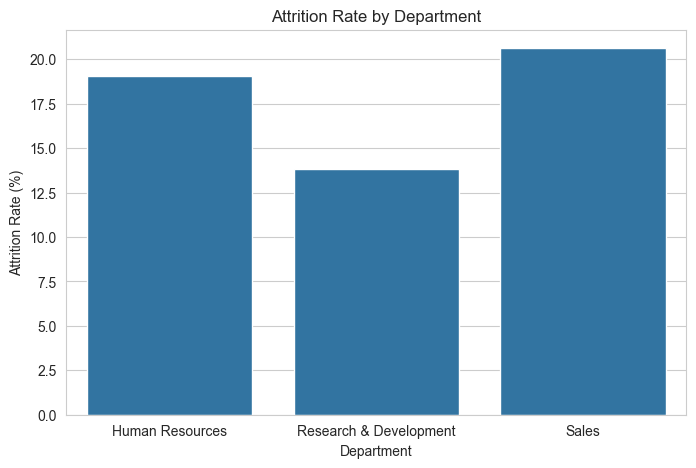

In [7]:
dept_attrition = (
    df.groupby('Department')['Attrition']
    .apply(lambda x: (x == 'Yes').mean()*100)
    .reset_index(name='Attrition Rate')
)

plt.figure(figsize=(8,5))

sns.barplot(
    data=dept_attrition,
    x='Department',
    y='Attrition Rate'
)

plt.title('Attrition Rate by Department')
plt.ylabel('Attrition Rate (%)')
plt.xlabel('Department')

plt.show()

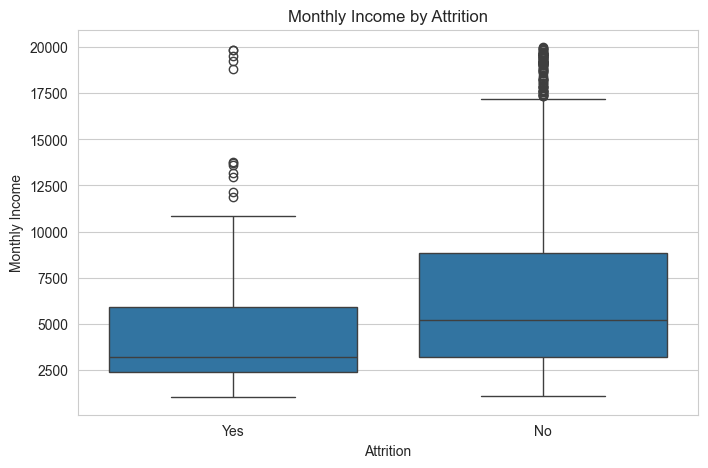

In [8]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Attrition',
    y='MonthlyIncome'
)

plt.title('Monthly Income by Attrition')
plt.xlabel('Attrition')
plt.ylabel('Monthly Income')

plt.show()

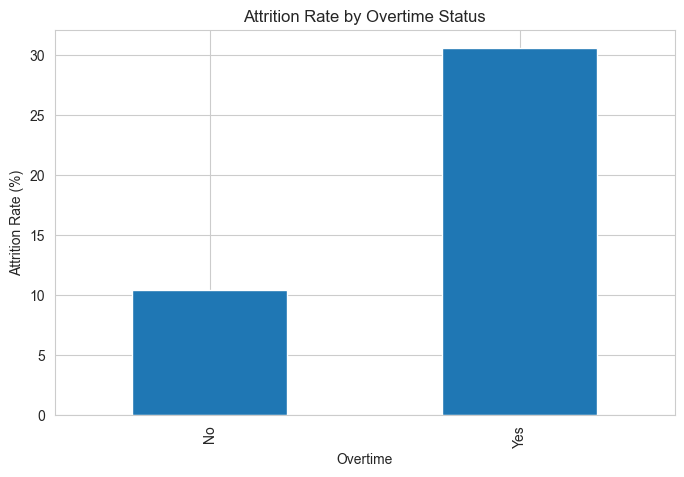

In [9]:
overtime_attrition = pd.crosstab(
    df['OverTime'],
    df['Attrition'],
    normalize='index'
) * 100

overtime_attrition['Yes'].plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Attrition Rate by Overtime Status')
plt.xlabel('Overtime')
plt.ylabel('Attrition Rate (%)')

plt.show()

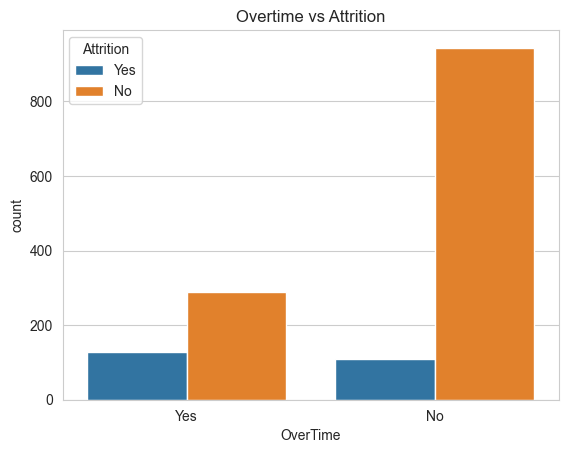

In [10]:
sns.countplot(
    data=df,
    x='OverTime',
    hue='Attrition'
)

plt.title('Overtime vs Attrition')
plt.show()

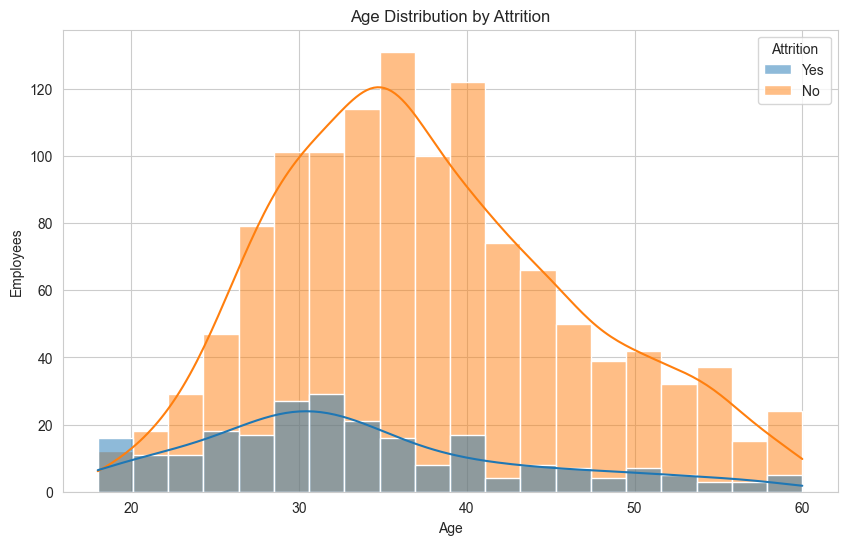

In [11]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x='Age',
    hue='Attrition',
    bins=20,
    kde=True,
    multiple='layer'
)

plt.title('Age Distribution by Attrition')
plt.xlabel('Age')
plt.ylabel('Employees')

plt.show()

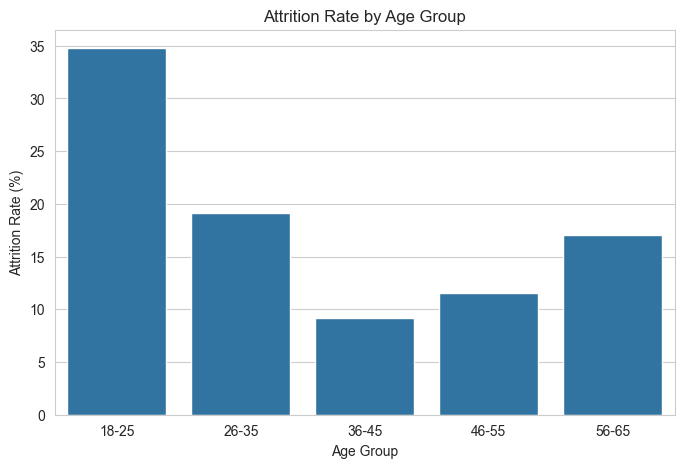

In [12]:
df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=[18,25,35,45,55,65],
    labels=['18-25','26-35','36-45','46-55','56-65']
)

age_attrition = (
    df.groupby('AgeGroup')['Attrition']
      .apply(lambda x: (x == 'Yes').mean()*100)
      .reset_index(name='AttritionRate')
)

plt.figure(figsize=(8,5))

sns.barplot(
    data=age_attrition,
    x='AgeGroup',
    y='AttritionRate'
)

plt.title('Attrition Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Attrition Rate (%)')

plt.show()

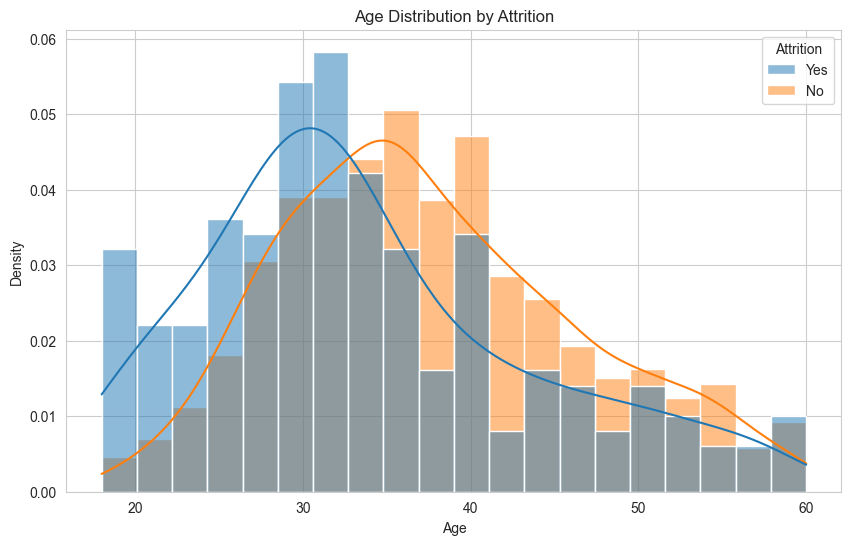

In [13]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x='Age',
    hue='Attrition',
    stat='density',
    common_norm=False,
    kde=True,
    bins=20
)

plt.title('Age Distribution by Attrition')
plt.xlabel('Age')
plt.ylabel('Density')

plt.show()

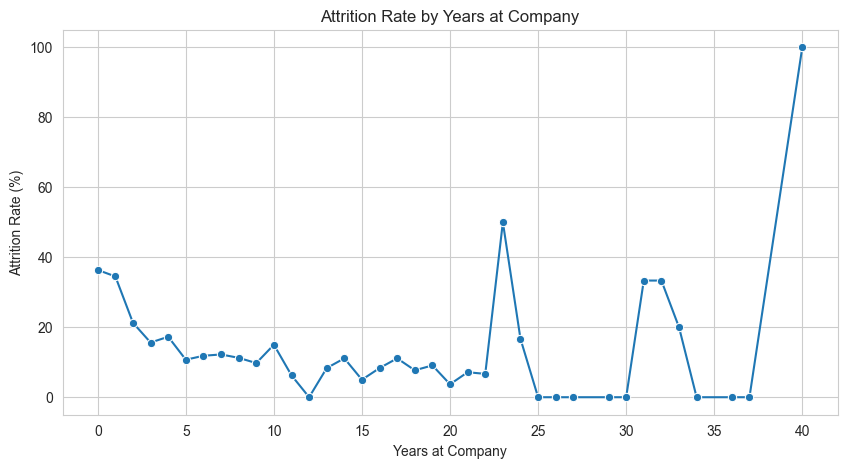

In [14]:
tenure_attrition = (
    df.groupby('YearsAtCompany')['Attrition']
    .apply(lambda x: (x == 'Yes').mean()*100)
    .reset_index(name='Attrition Rate')
)

plt.figure(figsize=(10,5))

sns.lineplot(
    data=tenure_attrition,
    x='YearsAtCompany',
    y='Attrition Rate',
    marker='o'
)

plt.title('Attrition Rate by Years at Company')
plt.xlabel('Years at Company')
plt.ylabel('Attrition Rate (%)')

plt.show()

In [15]:
tenure_count = (
    df.groupby('YearsAtCompany')
      .size()
      .reset_index(name='EmployeeCount')
)

print(tenure_count)

    YearsAtCompany  EmployeeCount
0                0             44
1                1            171
2                2            127
3                3            128
4                4            110
5                5            196
6                6             76
7                7             90
8                8             80
9                9             82
10              10            120
11              11             32
12              12             14
13              13             24
14              14             18
15              15             20
16              16             12
17              17              9
18              18             13
19              19             11
20              20             27
21              21             14
22              22             15
23              23              2
24              24              6
25              25              4
26              26              4
27              27              2
28            

In [16]:
tenure_stats = (
    df.groupby('YearsAtCompany')
      .agg(
          EmployeeCount=('Attrition', 'count'),
          AttritionRate=('Attrition',
                         lambda x: (x == 'Yes').mean() * 100)
      )
      .reset_index()
)

tenure_stats = tenure_stats[
    tenure_stats['EmployeeCount'] >= 10
]

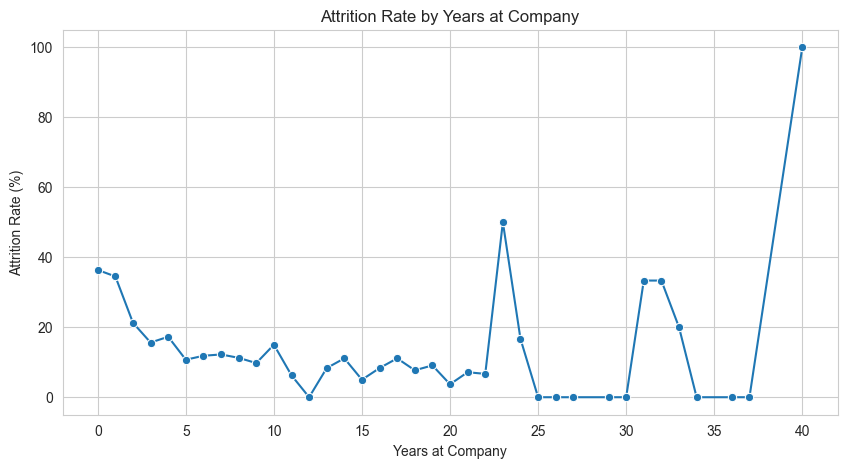

In [17]:
tenure_attrition = (
    df.groupby('YearsAtCompany')['Attrition']
    .apply(lambda x: (x == 'Yes').mean()*100)
    .reset_index(name='Attrition Rate')
)

plt.figure(figsize=(10,5))

sns.lineplot(
    data=tenure_attrition,
    x='YearsAtCompany',
    y='Attrition Rate',
    marker='o'
)

plt.title('Attrition Rate by Years at Company')
plt.xlabel('Years at Company')
plt.ylabel('Attrition Rate (%)')

plt.show()

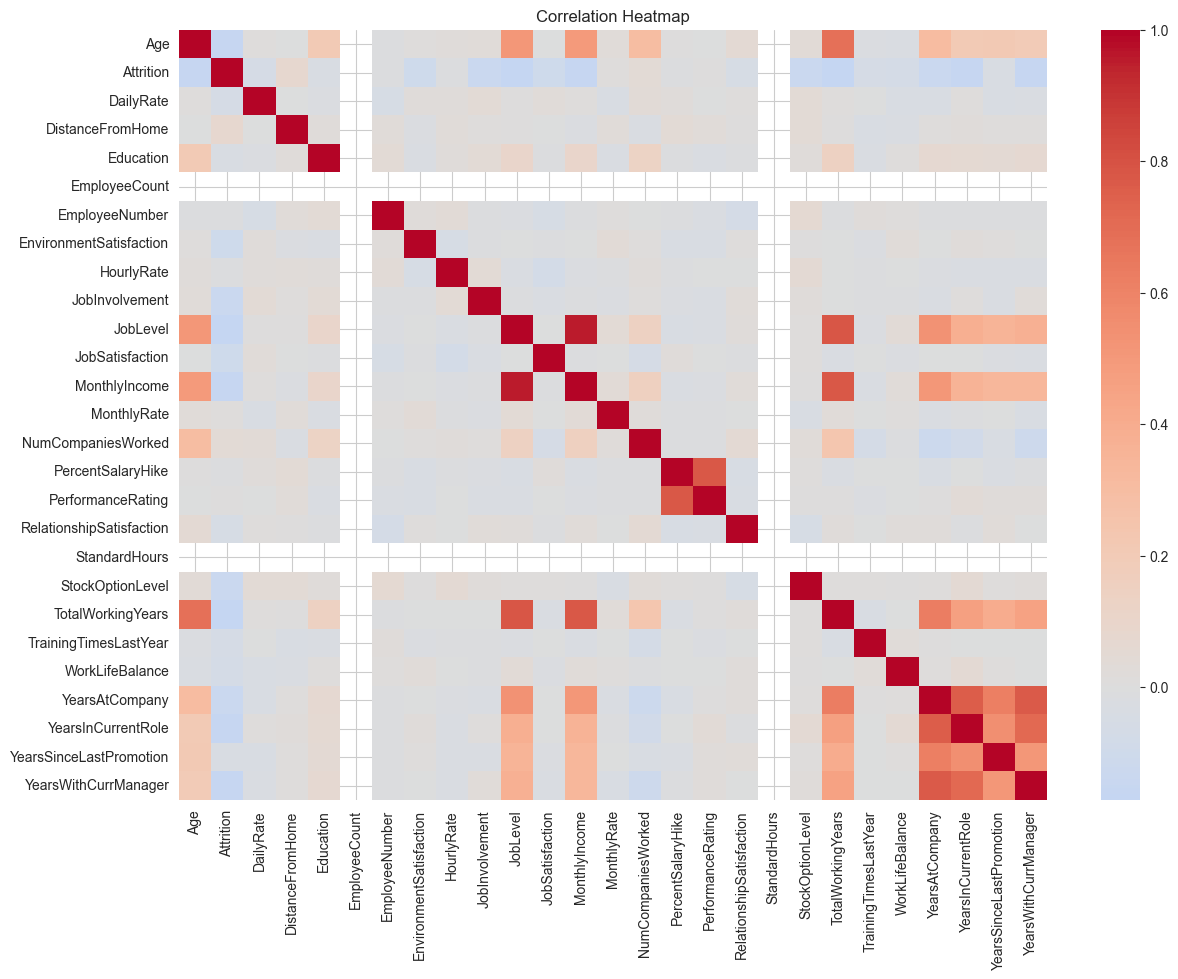

In [18]:
df_corr = df.copy()

df_corr['Attrition'] = (
    df_corr['Attrition']
    .map({'No':0,'Yes':1})
)

numeric_df = df_corr.select_dtypes(
    include=['int64','float64']
)

plt.figure(figsize=(14,10))

sns.heatmap(
    numeric_df.corr(),
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Heatmap')

plt.show()

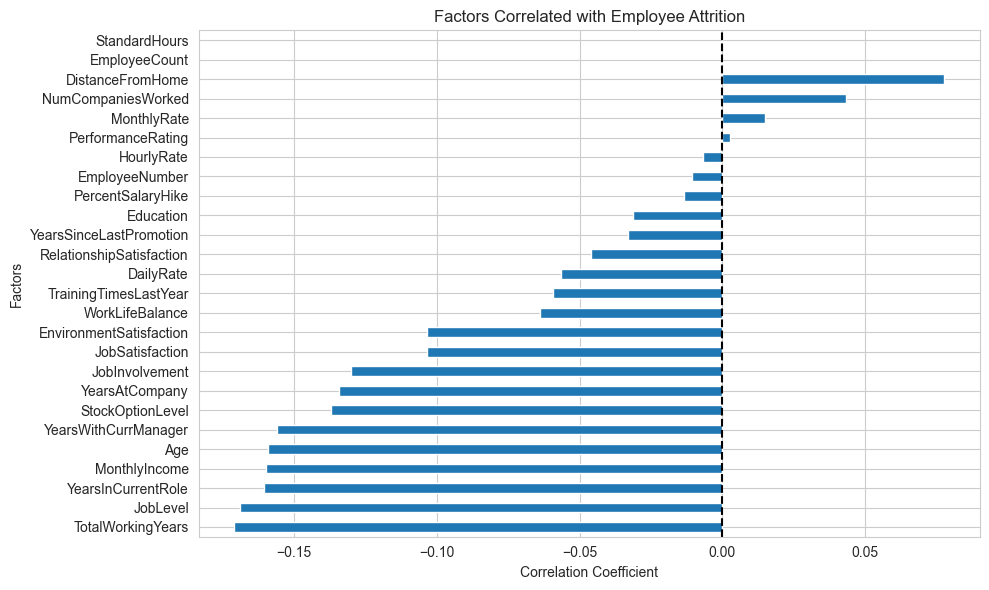

In [19]:
# Visualization 6 — Factors Correlated with Attrition

import matplotlib.pyplot as plt

# Convert Attrition to numeric
df_corr = df.copy()

df_corr['Attrition'] = df_corr['Attrition'].map({
    'No': 0,
    'Yes': 1
})

# Select only numeric columns
numeric_df = df_corr.select_dtypes(include=['int64', 'float64'])

# Calculate correlation with Attrition
corr_attrition = (
    numeric_df.corr()['Attrition']
    .drop('Attrition')
    .sort_values()
)

# Plot
plt.figure(figsize=(10, 6))

corr_attrition.plot(
    kind='barh'
)

plt.title('Factors Correlated with Employee Attrition')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Factors')

plt.axvline(
    x=0,
    color='black',
    linestyle='--'
)

plt.tight_layout()
plt.show()